In [1]:
%load_ext autoreload
%autoreload 2

import warnings 
from pathlib import Path
from typing import Optional
from collections import defaultdict
from functools import partial

from tqdm import tqdm

import jax
import jax.numpy as jnp
from jax import jit, grad
jax.config.update("jax_enable_x64", True)

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from source.features import PPNFeature, prepare_fmap
from source.data_functions import load_transform_data
from source.evaluation import rmse, nll, l2_gb_loss, norm_frob
from source.var_model import process_weights, hess_cov_estimation, jacob_cpd
from source.optimizer import als_cpd, lbfgs_cpd, adam_cpd, gauss_newton_cpd
from source.optimization import full_grid
from source.model_functionality import check_zero_cols, init_weights, predict_score
from source.general_functions import update_results_dict, create_dir_if_not_exists, query_df
from source.matrix_operations import ten3tovec, khatri_rao_row
from source.prob_functions import predict_std, w_sample
from source.visuals import PARAMS, plot_mtx_list, plot_mtx

warnings.filterwarnings("ignore")
sns.set_theme()

DATA_DIR = Path('./data')

grad_w = jit(grad(l2_gb_loss, argnums=0), static_argnums=(4, 7))

In [2]:
def plot_y_list( 
    y_list,
    x = None,
    leg_list=None,
    xlabel = 'Step',
    ylabel = 'Loss',
    title = '',
    x_scale='linear',
    y_scale='linear', # 'log'
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    text: Optional[str] = None,  
):
    if x is None:
        x = np.arange(len(y_list[0]))
    with mpl.rc_context(PARAMS):
        plt.figure(figsize=(8, 4))
        for i, y in enumerate(y_list): 
            plt.plot(x, y, marker='*', linestyle='-', label='' if leg_list is None else leg_list[i]) 
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xscale(x_scale)
        plt.yscale(y_scale)
        plt.title(title)
        if leg_list:
            plt.legend()
        plt.tight_layout()
        if text:
            plt.text(
                1.05, 0.5, text, transform=plt.gca().transAxes, 
                fontsize=9, color='black', va='center'
            )
        if save_path: 
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

LOSS_STR = 'Context:\n' + r'$\mathcal{J}(\mathbf{v}) = 0.5*(\beta \|\mathbf{y} - \mathbf{\Phi} \mathbf{g}(\mathbf{v})\|^2_2 + \gamma \|\mathbf{v}\|_2^2)$'

def get_name(p_dict): 
    return (
        f"I{p_dict['m_order']}_R{p_dict['rank']}_G{p_dict['gamma_w']}_S{p_dict['seed']}"
        + f"_E{p_dict['n_epoch']}_B{p_dict['beta_e']}_F{p_dict['fmap']}"
    )

def get_text(
    n_samples=None, 
    d_dim=None, 
    m_order=None, 
    rank=None, 
    beta_e=None, 
    gamma_w=None, 
    n_epoch=None, 
    fmap=None,
    seed=None,
):
    text = LOSS_STR + '\n'
    if n_samples is not None:
        text += f'N={n_samples}; '
    if d_dim is not None:
        text += f'D={d_dim}; '
    if m_order is not None:
        text += f'I={m_order}; '
    if rank is not None:
        text += f'R={rank}; '
    text += '\n'
    if beta_e is not None:
        text += r'$\beta$=' + f'{beta_e:.2e}; '
    if gamma_w is not None:
        text += r'$\gamma$=' + f'{gamma_w:.2e}; '
    text += '\n'
    if n_epoch is not None:
        text += f'E={n_epoch}; '
    if fmap is not None:
        text += r'$\mathbf{\psi}(x)$-' + f'{fmap}; '
    text += '\n'
    return text


def plot_prediction(
    y_gt, 
    y_mean, 
    y_std, 
    xlabel='',
    ylabel='',
    xscale='linear',
    yscale='linear',
    title='',
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
    ylim: Optional[tuple] = None
):
    y_lower = y_mean - y_std
    y_upper = y_mean + y_std
    with mpl.rc_context(PARAMS):
        plt.figure(figsize=(8, 4))
        plt.plot(y_gt, '*r', label='GT')
        plt.plot(y_mean, '+b', label='Mean')
        plt.fill_between(
            np.arange(len(y_mean)), 
            y_lower, 
            y_upper, 
            color='blue', 
            alpha=0.1, 
            label='±1 Std'
        )
        if ylim: plt.ylim(*ylim) 
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.xscale(xscale)
        plt.yscale(yscale)
        plt.title(title)
        plt.legend(loc='upper right')
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot: 
            plt.show()
        else: 
            plt.close()


import os
import imageio
from pathlib import Path

def generate_prediction_gif(
    x_vals,
    y_gt,
    means_list,
    stds_list,
    save_gif_path,
    temp_dir='temp_gif_frames',
    xlabel='',
    ylabel='',
    title_prefix='Frame',
    duration=0.5,
    ylim=None,
):
    os.makedirs(temp_dir, exist_ok=True)
    frame_paths = []

    for i, (th, y_mean, y_std) in enumerate(zip(x_vals, means_list, stds_list)):
        title = title_prefix + r'$\hat{t}=$' + f'{th:.1e}'
        frame_path = os.path.join(temp_dir, f'frame_{i:03d}.png')
        plot_prediction(
            y_gt, y_mean, y_std,
            xlabel=xlabel,
            ylabel=ylabel,
            title=title,
            save_path=frame_path,
            show_plot=False,
            ylim=ylim
        )
        frame_paths.append(frame_path)

    # Create GIF
    images = [imageio.imread(path) for path in frame_paths]
    imageio.mimsave(save_gif_path, images, duration=duration, loop=0)

    # Optionally: clean up frames
    for path in frame_paths:
        os.remove(path)
    os.rmdir(temp_dir)


def plot_dual_axis( 
    y1, 
    y2,
    x=None,
    leg_y1='',
    leg_y2='',
    xlabel='',
    y1_label='',
    y2_label='',
    x_scale='linear', # 'log'
    y1_scale='linear', # 'log'
    y2_scale='linear', # 'log'
    title='',
    save_path: Optional[str] = None,
    show_plot: bool = True,
    dpi: int = 200,
):
    if x is None:
        x = np.arange(len(y1))
    with mpl.rc_context(PARAMS):
        fig, ax1 = plt.subplots(figsize=(8, 4))
        # First Y-axis (Loss)
        ax1.plot(x, y1, marker='*', linestyle='-', color='b', label=leg_y1)
        ax1.set_xscale(x_scale)
        ax1.set_xlabel(xlabel)
        ax1.set_yscale(y1_scale)
        ax1.set_ylabel(y1_label, color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        # Second Y-axis (Gradient Norm)
        ax2 = ax1.twinx()
        ax2.plot(x, y2, marker='o', linestyle='--', color='r', label=leg_y2)
        ax2.set_yscale(y2_scale)
        ax2.set_ylabel(y2_label, color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        # Add legends
        ax2.legend(loc="lower right", bbox_to_anchor=(1.0, 0.70))
        ax1.legend(loc="upper right", bbox_to_anchor=(1.0, 0.95))
        #plt.xticks(x)
        plt.title(title)
        plt.grid(False)
        plt.tight_layout()
        if save_path: 
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

def zero_diagonal_blocks(matrix, block_size):
    n = matrix.shape[0]
    modified_matrix = np.array(matrix.copy())
    for i in range(0, n, block_size):
        modified_matrix[i:i+block_size, i:i+block_size] = 0  # Set diagonal block to zero
    return modified_matrix

def save_dict_np(dt, save_path) -> None:
    numpy_dict = {k: np.array(v) for k, v in dt.items()}
    np.savez(save_path, **numpy_dict)

def load_dict_jax(load_path) -> dict:
    loaded = np.load(load_path)
    return {k: jnp.array(v) for k, v in loaded.items()}

### Test NLL Real Data (14.04.2025):

- Compare Low-rank Full(GN), Block Diagonal, MeanField covariance matrix
- Use RMSE and NLL on train and test to check the performance
- Should we use Full Covariance?
- Check Simple 1HNN, Non-Tensorized model, GP and CP-Tensorized Model.

#### Linearized Laplace Model:

In [ ]:
def est_linear_w(x, y):
    pass

def neg_model_evidence(gamma_w, w_vec, hess):
    return 0.5*(gamma_w*(w_vec*w_vec).sum() + jnp.log(jnp.linalg.det(1/gamma_w * hess + jnp.ones_like(hess))))

def est_linear_gamma():
    pass

#### CP-Tensorized Model:

In [105]:
def train_model(x, y, grad_w, opt, conf):
    fmap, dtype = prepare_fmap(conf['fmap'], conf['m_order'], is_quant=False)
    w_ten, kd = init_weights(conf['m_order'], conf['rank'], x.shape[1], q_base=None, init_type=None, seed=conf['seed'], dtype=dtype)
    w_vec, w_shape = ten3tovec(w_ten), w_ten.shape
    if opt == 'als':
        w_vec, tracker = als_cpd(
            w_vec, kd, w_shape, x, y, fmap, 
            conf['n_epoch'], conf['gamma_w'], conf['beta_e'], grad_w
        )
    elif opt == 'lbfgs':
        w_vec, _ = lbfgs_cpd(
            w_vec, kd, w_shape, x, y, fmap, 
            conf['n_epoch'], conf['gamma_w'], conf['beta_e'], grad_w, tol=1e-6,
        )
        tracker = dict(loss=[l2_gb_loss(ten3tovec(w_ten), kd, x, y, fmap, conf['gamma_w'], conf['beta_e'], w_shape).item()],
            grad_norm=[norm_frob(grad_w(ten3tovec(w_ten), kd, x, y, fmap, conf['gamma_w'], conf['beta_e'], w_shape)).item()]
        )
    elif opt == 'adam':
        lr, bs = 3e-2, 64
        w_vec, tracker = adam_cpd(w_vec, kd, w_shape, x, y, fmap, conf['n_epoch'], conf['gamma_w'], conf['beta_e'], grad_w, lr, bs)
    elif opt == 'lm':
        lm_mode, lambda_init = True, 1e-3
        w_vec, tracker = gauss_newton_cpd(w_vec, kd, w_shape, x, y, fmap, conf['n_epoch'], conf['gamma_w'], conf['beta_e'], grad_w, lm_mode, lambda_init)
        
    w_ten, w_shape = process_weights(w_vec, w_shape)
    # Hessian/Covariance/Cholesky Evaluation:
    w_hess, w_cov, w_cholesky = hess_cov_estimation(
        w_ten, kd, x, y, fmap, conf['gamma_w'], 
        conf['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    return fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker

def compute_stats(data, fmap, conf, w_ten, kd, w_hess, w_cholesky, tracker):
    x, x_test, y, y_test = data
    D, I, R = w_ten.shape
    ys_train = predict_score(x, kd, w_ten, fmap)
    ys_test = predict_score(x_test, kd, w_ten, fmap)
    ys_var_test = predict_std(w_ten, w_cholesky, kd, x_test, fmap, conf['beta_e'], n_samples=30)**2
    w_hess_evals = np.linalg.eigvals(w_hess).real
    
    v_check = (0, int(conf['n_epoch'] // 2), conf['n_epoch']-1)
    gd_down = [v for i, v in enumerate(tracker['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_var_test, y_test), loss=tracker['loss'][-1], 
        w_norm = norm_frob(w_ten).item(), gd_norm=tracker['grad_norm'][-1],
        w_new_rank=(~check_zero_cols(w_ten).all(axis=0)).sum().item(),
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
        hess_norm_off_bd=norm_frob(zero_diagonal_blocks(w_hess, I*R)).item()
    )
    return res_dict

def save_stats():
    pass

In [106]:
DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
OPT = 'als' # DO NOT CHANGE ALS !!!!!!!!!!!!!!!!!
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

RES_DIR = Path(f'./artifacts/cov_comparison/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(
    m_order=[8,],
    rank=[10,],
    fmap=[PPNFeature(),],
    gamma_w=[1e-6,],
    beta_e=[1.0,],
    n_epoch=[100,],
    seed=[13,],
    hess_type=['mf', 'full', 'block'],
    low_rank=[True,],
    low_rank_th=[1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
)
grid, param_names = full_grid(params)
if TRAIN:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_model(
            x, y, grad_w, OPT, conf
        )
        stats = compute_stats(dt, fmap, conf, w_ten, kd, w_hess, w_cholesky, tracker)
        update_results_dict(res_dict, **stats, **conf)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(RES_DIR / 'nll_info.csv')
else:
    res_df = pd.read_csv(RES_DIR / 'nll_info.csv', index_col=0)

In [ ]:
display(res_df.sort_values(by='nll_test'))

##### Compare Hessian Estimators:

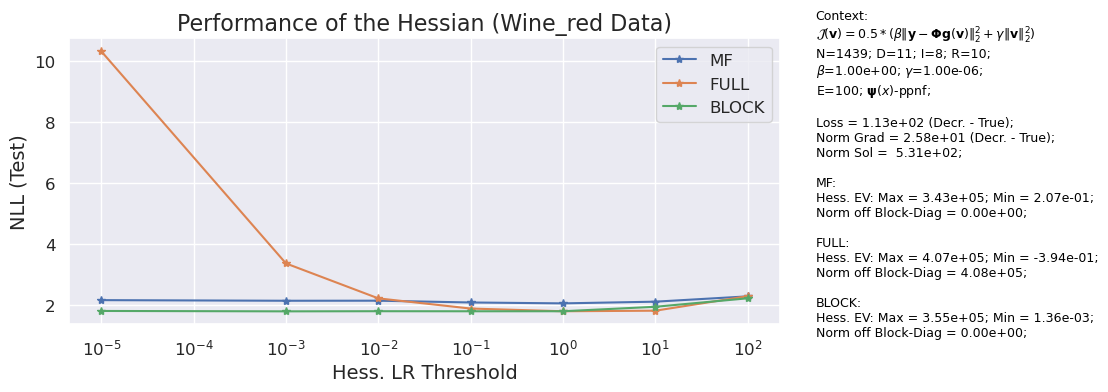

In [108]:
SAVE_DIR = Path(f'./artifacts/cov_comparison/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]
    text_list.append(
        (
            f'\n{hess_type.upper()}:\n'
            + f'Hess. EV: Max = {tdf["max_ev"].iloc[0]:.2e}; Min = {tdf["min_ev"].iloc[0]:.2e};\n'
            #+ f'Cholesky shape = {tdf["w_chol_shape"].iloc[0]};\n'
            + f'Norm off Block-Diag = {tdf["hess_norm_off_bd"].iloc[0]:.2e};\n'
        )
    )

p_fixed = {k:v[0] for k, v in params.items() if k not in ['hess_type', 'low_rank', 'low_rank_th']}
p_fixed['fmap'] = p_fixed['fmap'].name

loss_val = res_df['loss'][0]
loss_dec = res_df['loss_down'][0]
gd_norm_val = res_df['gd_norm'][0]
gd_norm_dec = res_df['gd_down'][0]
w_norm = res_df['w_norm'][0]

text = get_text(n_samples, d_dim, **p_fixed)
text += (
    f'\nLoss = {loss_val:.2e} (Decr. - {loss_dec});\n'
    + f'Norm Grad = {gd_norm_val:.2e} (Decr. - {gd_norm_dec});\n'
    + f'Norm Sol = {w_norm: .2e};\n'
)
for v in text_list:
    text += v

title = f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    title=title, x_scale='log', text=text,
    save_path=save_path
)

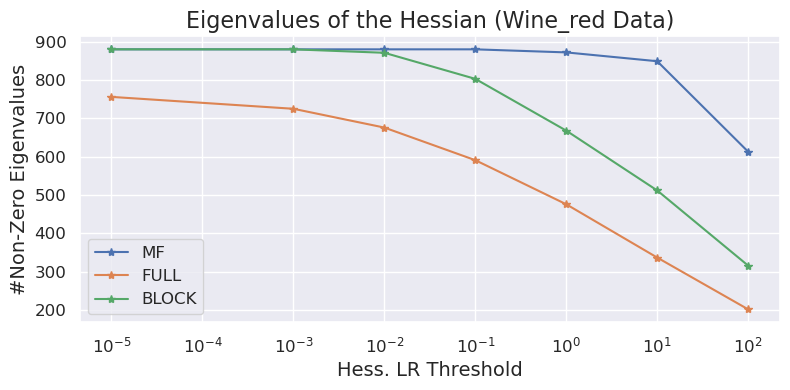

In [109]:
x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

title = f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)'

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    title=title, x_scale='log',
    save_path=None
)

##### Predictive Distribution:

In [110]:
SAVE_DIR = Path(f'./artifacts/cov_comparison/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

hess_type = 'block'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}

fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_model(
    x, y, grad_w, OPT, conf
)

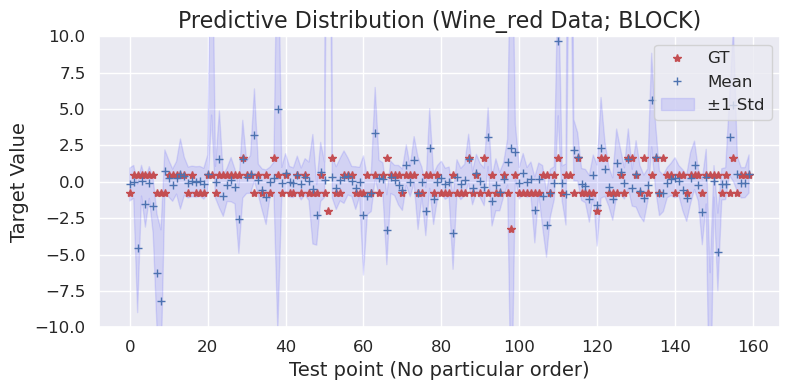

In [111]:
ys_test = predict_score(x_test, kd, w_ten, fmap)
ys_std_test = predict_std(w_ten, w_cholesky, kd, x_test, fmap, p_fixed['beta_e'], n_samples=50) 

title = f'Predictive Distribution ({DATA_NAME.capitalize()} Data; {hess_type.upper()})'
save_path = SAVE_DIR / f'{DATA_NAME}_pred_dist.png'
plot_prediction(
    y_test, ys_test, ys_std_test, 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=title,
    save_path=save_path,
    ylim=(-10, 10)
)

In [112]:
hess_type = 'block'
changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}

means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_model(
        x, y, grad_w, OPT, conf
    )
    mean = predict_score(x_test, kd, w_ten, fmap)
    std = predict_std(w_ten, w_cholesky, kd, x_test, fmap, 1, n_samples=50)
    means_list.append(mean)
    stds_list.append(std)

title = f'Predictive Distribution. {hess_type.upper()}, '
save_path = SAVE_DIR / f'{DATA_NAME}_pred_dist.gif'
generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=save_path,
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=title,
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

100%|██████████| 7/7 [02:55<00:00, 25.01s/it]


##### Eigenvalues?

In [ ]:
opt = 'als'
conf = {k:v[0] for k, v in params.items()}

hess_dict = {}
for hess_type in params['hess_type']:
    conf['hess_type'] = hess_type
    fmap, w_ten, kd, w_hess, w_cov, w_cholesky, tracker = train_model(x, y, grad_w, opt, conf)
    hess_dict[hess_type] = np.array(w_hess)

In [ ]:
SAVE_DIR = Path(f'./artifacts/cov_comparison/{DATA_NAME}/results/')

y_list = []
for hess_type in params['hess_type']:
    ys = []
    for th in params['low_rank_th']:
        w_hess = hess_dict[hess_type]
        s, u = np.linalg.eigh(w_hess)
        mask = s >= th
        ys.append(1/min(s[mask]))
        #print(th, hess_type, 1/min(s[mask]))
    y_list.append(ys)

x_range = params['low_rank_th']
leg_list = params['hess_type']

title = f'Estimate Pred. Dist. Variance ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / f'{DATA_NAME}_cov_max_ev_th.png'
plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold (log)', 
    ylabel='Max Cov. Eigenvalue (log)',
    x_scale='log',
    y_scale='log',
    title=title,
    save_path=save_path
)

In [ ]:
D, I, R = w_ten.shape
norm_frob(zero_diagonal_blocks(L.dot(L.T), I*R))
norm_frob(L.dot(L.T) - w_hess)

#### Non-Tensorized Model:

In [59]:
from source.var_model import cov_estimation, low_rank_cov_estimation

def ls_sol(x, y, fmap, gamma_w, beta_e):
    F_mtx = get_design_mtx(x, fmap)
    A_mtx = beta_e*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])
    b = beta_e*F_mtx.T.conj().dot(y)
    return A_mtx, jnp.linalg.solve(A_mtx, b)

def train_model_pure(x, y, grad_w, conf):
    fmap, _ = prepare_fmap(conf['fmap'], conf['m_order'], is_quant=False)
    w_hess, w_vec = ls_sol(x, y, fmap, conf['gamma_w'], conf['beta_e'])
    tracker = defaultdict(list)
    update_results_dict(
        tracker, loss=l2_reg_loss(w_vec, x, y, fmap, conf['gamma_w'], conf['beta_e']).item(),
        grad_norm=norm_frob(grad_w(w_vec, x, y, fmap, conf['gamma_w'], conf['beta_e'])).item(),
    )
    if conf['hess_type'] == 'full': w_hess = w_hess
    elif conf['hess_type'] == 'mf': w_hess = jnp.diag(jnp.diagonal(w_hess))
    else: assert False

    if conf['low_rank']: cov_f = partial(low_rank_cov_estimation, threshold=conf['low_rank_th'])
    else: cov_f = cov_estimation
    
    try: w_cov, w_cholesky = cov_f(w_hess); 
    except Exception as e: w_cov, w_cholesky = None, None

    return fmap, w_vec, w_hess, w_cov, w_cholesky, tracker

def predict_score(w_vec, x, fmap):
    return jnp.real(get_design_mtx(x, fmap).dot(w_vec))

def l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e):
    scores = predict_score(w_vec, x, fmap)
    return 0.5*(beta_e*jnp.sum((y - scores)**2) + gamma_w*(w_vec * w_vec).sum())

def get_design_mtx(x, fmap):
    design_mtx = fmap(x[:, 0], None)
    for k in range(1, x.shape[1]):
        design_mtx = khatri_rao_row(fmap(x[:, k], None), design_mtx)
    return design_mtx

def predict_std_pure(w_vec, w_cholesky, x, fmap, beta_e, n_samples=10):
    preds = []
    for _ in range(n_samples):
        w_vec_sample = w_sample(w_vec, w_cholesky)
        scores = predict_score(w_vec_sample, x, fmap)
        preds.append(scores[:, None])
    pred_std = jnp.std(jnp.hstack(preds), axis=1)
    std_err = 1 / jnp.sqrt(beta_e)
    return pred_std + std_err

def compute_stats_pure(data, fmap, conf, w_vec, w_hess, w_cholesky, tracker):
    x, x_test, y, y_test = data
    ys_train = predict_score(w_vec, x, fmap)
    ys_test = predict_score(w_vec, x_test, fmap)
    ys_var_test = predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50)**2
    w_hess_evals = np.linalg.eigvals(w_hess).real
    
    v_check = (0, int(conf['n_epoch'] // 2), conf['n_epoch']-1)
    gd_down = [v for i, v in enumerate(tracker['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_var_test, y_test), loss=tracker['loss'][-1], 
        w_norm = norm_frob(w_vec).item(), gd_norm=tracker['grad_norm'][-1],
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
    )
    return res_dict

grad_w_pure = jit(grad(l2_reg_loss, argnums=0), static_argnums=(3,))

##### Train Pure Model:

In [85]:
DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = True

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

RES_DIR = Path(f'./artifacts/cov_comparison/pure_model/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(m_order=[2,], fmap=[PPNFeature(),], gamma_w=[1e-6,], beta_e=[1.0,],
    n_epoch=[1,], seed=[13,], hess_type=['mf', 'full'], low_rank=[True,],
    low_rank_th=[1e-6, 1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
)
grid, param_names = full_grid(params)
if TRAIN:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
        stats = compute_stats_pure(dt, fmap, conf, w_vec, w_hess, w_cholesky, tracker)
        update_results_dict(res_dict, **stats, **conf)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(RES_DIR / 'nll_info.csv')
else:
    res_df = pd.read_csv(RES_DIR / 'nll_info.csv', index_col=0)

SAVE_DIR = Path(f'./artifacts/cov_comparison/pure_model/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

100%|██████████| 16/16 [00:47<00:00,  2.98s/it]


PosixPath('artifacts/cov_comparison/pure_model/wine_red/results')

##### Hessian Estimators:

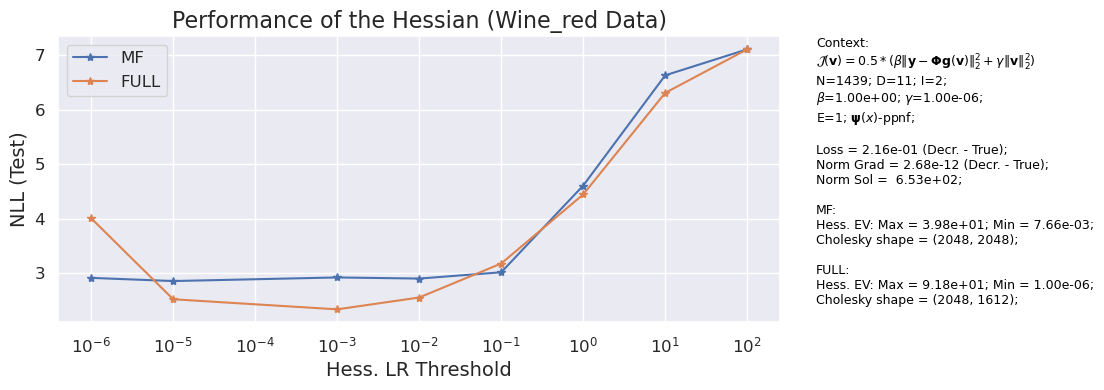

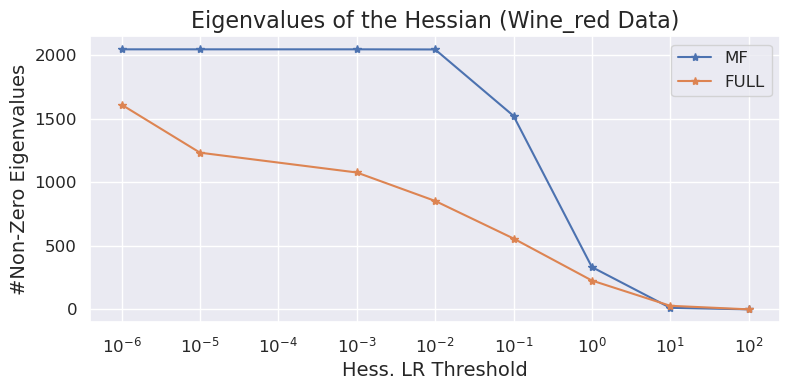

In [86]:
x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]
    text_list.append(
        (
            f'\n{hess_type.upper()}:\n'
            + f'Hess. EV: Max = {tdf["max_ev"].iloc[0]:.2e}; Min = {tdf["min_ev"].iloc[0]:.2e};\n'
            + f'Cholesky shape = {tdf["w_chol_shape"].iloc[0]};\n'
        )
    )

p_fixed = {k:v[0] for k, v in params.items() if k not in ['hess_type', 'low_rank', 'low_rank_th']}
p_fixed['fmap'] = p_fixed['fmap'].name

loss_val, loss_dec = res_df['loss'][0], res_df['loss_down'][0]
gd_norm_val, gd_norm_dec = res_df['gd_norm'][0], res_df['gd_down'][0]
w_norm = res_df['w_norm'][0]

text = get_text(n_samples, d_dim, **p_fixed)
text += (
    f'\nLoss = {loss_val:.2e} (Decr. - {loss_dec});\n'
    + f'Norm Grad = {gd_norm_val:.2e} (Decr. - {gd_norm_dec});\n'
    + f'Norm Sol = {w_norm: .2e};\n'
)
for v in text_list:
    text += v

title = f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)'
save_path = SAVE_DIR / f'{DATA_NAME}_hess_perf.png'

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=text,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    x_scale='log',
    title=f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_nonzero_ev.png'
)

##### Predictive Distribution:

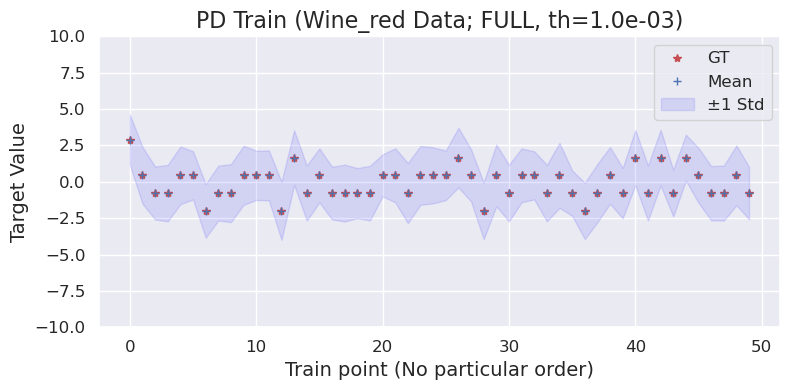

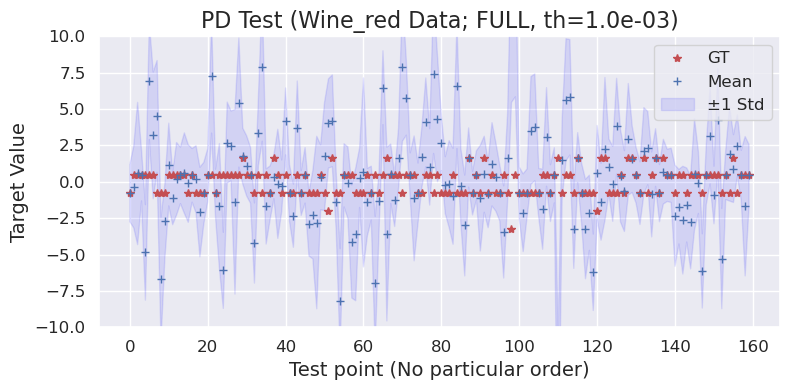

In [87]:
hess_type = 'full'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}

fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)

n_train_show = 50
plot_prediction(
    y[:n_train_show], 
    predict_score(w_vec, x[:n_train_show, :], fmap), 
    predict_std_pure(w_vec, w_cholesky, x[:n_train_show, :], fmap, conf['beta_e'], n_samples=50),
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    predict_score(w_vec, x_test, fmap), 
    predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {hess_type.upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-10, 10)
)

##### PD Gif:

In [88]:
means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
    
    mean = predict_score(w_vec, x_test, fmap)
    std = predict_std_pure(w_vec, w_cholesky, x_test, fmap, conf['beta_e'], n_samples=50)
    means_list.append(mean)
    stds_list.append(std)

generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.gif',
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=f'Predictive Distribution. {hess_type.upper()}, ',
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

100%|██████████| 8/8 [00:19<00:00,  2.40s/it]


##### Covariance Matrix Eigenvalues:

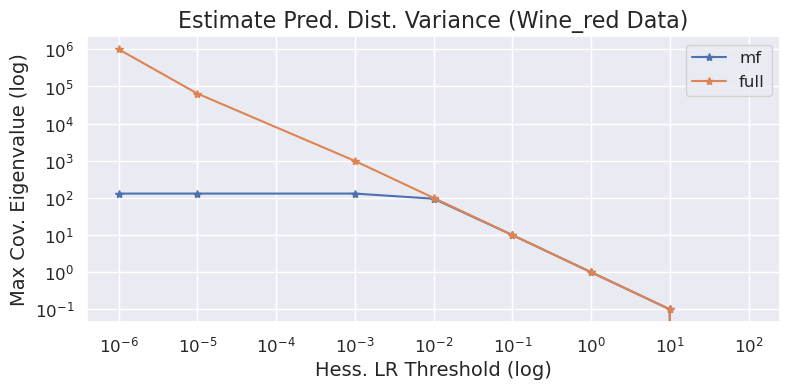

In [89]:
hess_dict, y_list = {}, []
for hess_type in params['hess_type']:
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=1e-1)
    fmap, w_vec, w_hess, w_cov, w_cholesky, tracker = train_model_pure(x, y, grad_w_pure, conf)
    hess_dict[hess_type] = np.array(w_hess)
    ys = []
    s, u = np.linalg.eigh(w_hess)
    for th in params['low_rank_th']:
        mask = s >= th
        if sum(mask) > 0:
            ys.append(1/min(s[mask]))
        else:
            ys.append(0)
    y_list.append(ys)

plot_y_list(
    y_list, 
    x=params['low_rank_th'], 
    leg_list=params['hess_type'], 
    xlabel='Hess. LR Threshold (log)', 
    ylabel='Max Cov. Eigenvalue (log)',
    x_scale='log',
    y_scale='log',
    title=f'Estimate Pred. Dist. Variance ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_cov_max_ev_th.png'
)

#### Simple NN:

In [3]:
from jax import random
from jax.flatten_util import ravel_pytree

from source.nn import (
    norm_nn,
    n_params,
    forward_nn,
    init_params,
    train_map_nn, 
    hess_cov_estimation_nn,
)

def train_model_nn(x, y, conf):
    key = random.PRNGKey(conf['seed'])
    nn_w = init_params(key, input_dim=x.shape[1], hidden_dim=conf['hidden_dim'], output_dim=1)
    nn_w_trained, tracker = train_map_nn(nn_w, x, y, conf['beta_e'], conf['gamma_w'], 
        conf['use_linesearch'], conf['opt_method'], conf['lr'], conf['n_epoch'])
    # Hessian/Covariance/Cholesky Evaluation:
    w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf['gamma_w'], 
        conf['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    return nn_w_trained, w_hess, w_cov, w_cholesky, tracker

def predict_std_nn(nn_w, w_cholesky, x, beta_e, n_samples=10):
    nn_w_vec, unflatten_fn = ravel_pytree(nn_w)
    preds = []
    for _ in range(n_samples):
        nn_w_vec_sample = w_sample(nn_w_vec, w_cholesky)
        nn_w_sample = unflatten_fn(nn_w_vec_sample)
        scores = forward_nn(nn_w_sample, x)
        preds.append(scores[:, None])
    pred_std = jnp.std(jnp.hstack(preds), axis=1)
    std_err = 1 / jnp.sqrt(beta_e)
    return pred_std + std_err

def compute_stats_nn(data, conf, nn_w, w_hess, w_cholesky, tracker):
    x, x_test, y, y_test = data
    ys_train = forward_nn(nn_w, x)
    ys_test = forward_nn(nn_w, x_test)
    ys_var_test = predict_std_nn(nn_w, w_cholesky, x_test, conf['beta_e'], n_samples=50)**2
    w_hess_evals = np.linalg.eigvals(w_hess).real
    
    v_check = (0, int(conf['n_epoch'] // 2), conf['n_epoch']-1)
    gd_down = [v for i, v in enumerate(tracker['grad_norm']) if i in v_check]
    loss_down = [v for i, v in enumerate(tracker['loss']) if i in v_check]
    
    res_dict = dict(
        rmse_train=rmse(y, ys_train), rmse_test=rmse(y_test, ys_test), 
        nll_test=nll(ys_test, ys_var_test, y_test), loss=tracker['loss'][-1], 
        w_norm=norm_nn(nn_w), 
        gd_norm=tracker['grad_norm'][-1],
        max_ev=max(w_hess_evals), min_ev=min(w_hess_evals), 
        w_chol_shape=f"{w_cholesky.shape}", 
        loss_down=loss_down == sorted(loss_down, reverse=True),
        gd_down=gd_down == sorted(gd_down, reverse=True),
    )
    return res_dict

##### Debug NN:

(N, D) =(277, 6)
P=641


{'rmse_train': 0.00030528829175064076,
 'rmse_test': 0.06645731013051488,
 'nll_test': 1.888488272509784,
 'loss': 9.856738086414512e-05,
 'w_norm': 19.87803864307355,
 'gd_norm': 0.00015951631575424738,
 'max_ev': 1643.656079521199,
 'min_ev': 0.40236206348872877,
 'w_chol_shape': '(641, 641)',
 'loss_down': True,
 'gd_down': True}

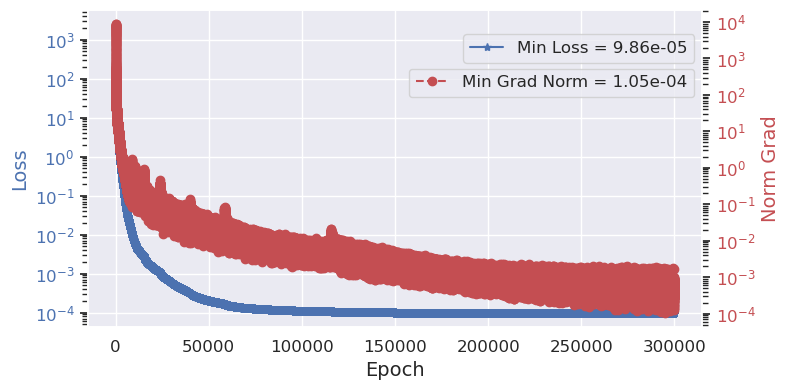

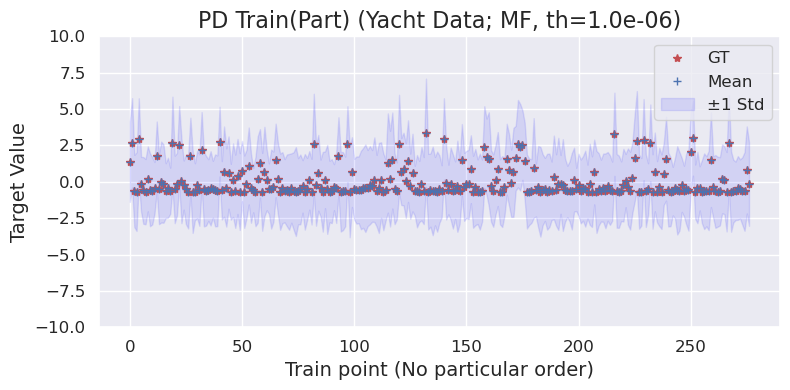

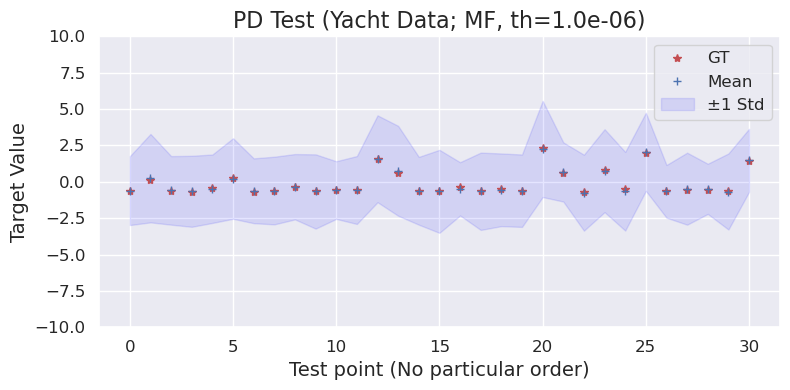

In [21]:
DATA_NAME = 'yacht' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
# Prepare the data:
x, x_test, y, y_test = load_transform_data(DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape
print(f"(N, D) ={ x.shape}")
conf = dict(
    gamma_w=1e-6, beta_e=1.0,
    hidden_dim=80, lr=1e-3, opt_method='adam', n_epoch=300000, use_linesearch=True,
    seed=13, hess_type='mf', low_rank=True, low_rank_th=1e-6,
)
nn_w_trained, w_hess, w_cov, w_cholesky, tracker = train_model_nn(x, y, conf)
stats = compute_stats_nn(dt, conf, nn_w_trained, w_hess, w_cholesky, tracker)
print(f"P={n_params(nn_w_trained)}")
display(stats)

plot_dual_axis( 
    tracker['loss'], 
    tracker['grad_norm'],
    x=None,
    leg_y1=f'Min Loss = {min(tracker["loss"]):.2e}',
    leg_y2=f'Min Grad Norm = {min(tracker["grad_norm"]):.2e}',
    xlabel='Epoch',
    y1_label='Loss',
    y2_label='Norm Grad',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title='',
    save_path=None,
    dpi=200,
)

plot_prediction(
    y, 
    forward_nn(nn_w_trained, x), 
    predict_std_nn(nn_w_trained, w_cholesky, x, conf['beta_e'], n_samples=50), 
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train(Part) ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=None,
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    forward_nn(nn_w_trained, x_test), 
    predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=None,
    ylim=(-10, 10)
)

##### Train NN:

In [9]:
DATA_NAME = 'energy' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = False

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

RES_DIR = Path(f'./artifacts/cov_comparison/neural_net/{DATA_NAME}/training_artifacts/')
create_dir_if_not_exists(RES_DIR)

params = dict(gamma_w=[1e-6,], beta_e=[1.0,], seed=[13,], 
    hidden_dim=[80,], lr=[1e-3,], opt_method=['adam',], n_epoch=[300000,], use_linesearch=[True,],
    hess_type=['mf', 'block', 'full'], low_rank=[True,], 
    low_rank_th=[1e-6, 1e-5, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2],
)
conf_map = {k:v[0] for k, v in params.items() if k in ['gamma_w', 'beta_e', 'seed', 'hidden_dim', 'lr', 'opt_method', 'n_epoch', 'use_linesearch']}
grid, param_names = full_grid(params)
if TRAIN:
    # Find MAP:
    conf_map = {k:v[0] for k, v in params.items() if k in ['gamma_w', 'beta_e', 'seed', 'hidden_dim', 'lr', 'opt_method', 'n_epoch', 'use_linesearch']}
    nn_w = init_params(random.PRNGKey(conf_map['seed']), input_dim=x.shape[1], hidden_dim=conf_map['hidden_dim'], output_dim=1)
    nn_w_trained, tracker = train_map_nn(nn_w, x, y, conf_map['beta_e'], conf_map['gamma_w'], 
        conf_map['use_linesearch'], conf_map['opt_method'], conf_map['lr'], conf_map['n_epoch']
    )
    save_dict_np(nn_w_trained, RES_DIR / 'map_weights.npz')
    save_dict_np(tracker, RES_DIR / 'map_tracker.npz')
    # Check Hesian:
    res_dict = defaultdict(list)
    for v in tqdm(grid):
        conf = dict(zip(param_names, v))
        w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
            nn_w_trained, x, y, conf_map['gamma_w'], 
            conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
        )
        stats = compute_stats_nn(dt, conf, nn_w_trained, w_hess, w_cholesky, tracker)
        update_results_dict(res_dict, **stats, **conf)
    res_df = pd.DataFrame(res_dict)
    res_df.to_csv(RES_DIR / 'nll_info.csv')
else:
    res_df = pd.read_csv(RES_DIR / 'nll_info.csv', index_col=0)
    nn_w_trained = load_dict_jax(RES_DIR / 'map_weights.npz')
    tracker = load_dict_jax(RES_DIR / 'map_tracker.npz')

SAVE_DIR = Path(f'./artifacts/cov_comparison/neural_net/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

PosixPath('artifacts/cov_comparison/neural_net/energy/results')

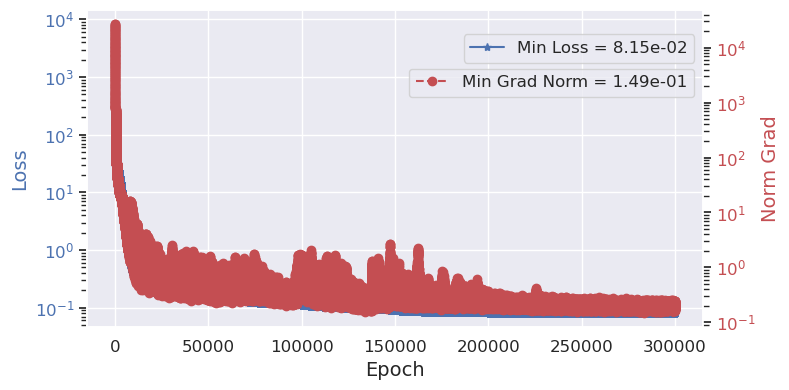

In [5]:
plot_dual_axis( 
    tracker['loss'], 
    tracker['grad_norm'],
    x=None,
    leg_y1=f'Min Loss = {min(tracker["loss"]):.2e}',
    leg_y2=f'Min Grad Norm = {min(tracker["grad_norm"]):.2e}',
    xlabel='Epoch',
    y1_label='Loss',
    y2_label='Norm Grad',
    x_scale='linear',
    y1_scale='log',
    y2_scale='log',
    title='',
    save_path=None,
    dpi=200,
)

##### Hessian Estimators:

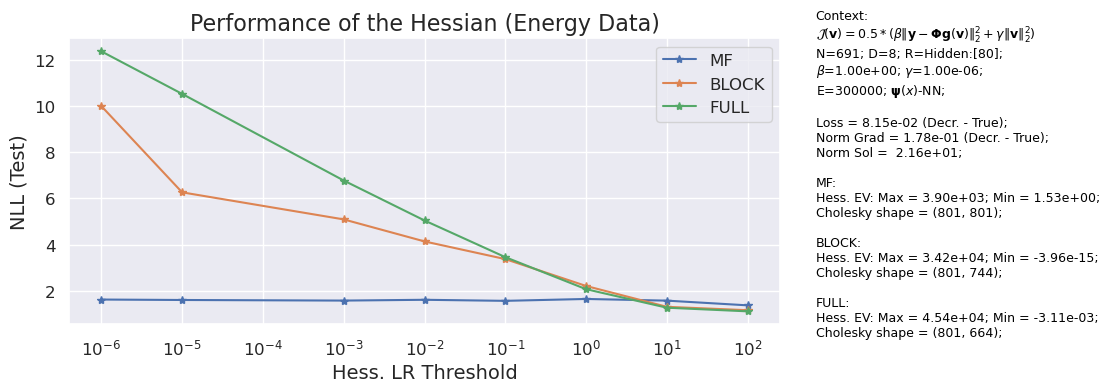

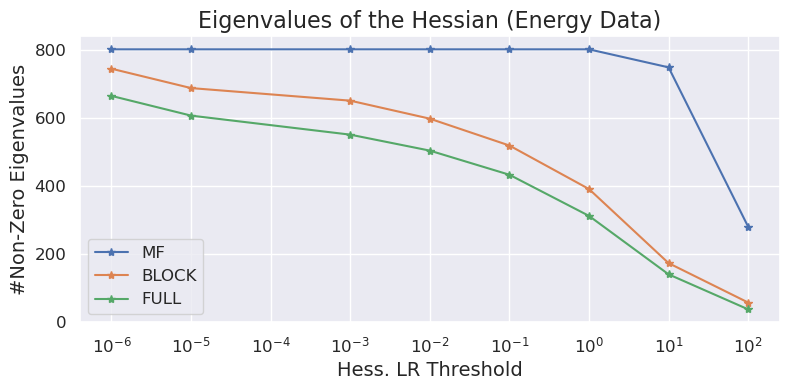

In [7]:
x_name, y_name = 'low_rank_th', 'nll_test'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append(tdf[y_name])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]
    text_list.append(
        (
            f'\n{hess_type.upper()}:\n'
            + f'Hess. EV: Max = {tdf["max_ev"].iloc[0]:.2e}; Min = {tdf["min_ev"].iloc[0]:.2e};\n'
            + f'Cholesky shape = {tdf["w_chol_shape"].iloc[0]};\n'
        )
    )
remove_cols = ['hess_type', 'low_rank', 'low_rank_th', 'hidden_dim', 'lr', 'opt_method', 'use_linesearch']
p_fixed = {k:v[0] for k, v in params.items() if k not in remove_cols}
p_fixed['fmap'] = 'NN'
p_fixed['rank'] = f"Hidden:{params['hidden_dim']}"
p_fixed['m_order'] = None

loss_val, loss_dec = res_df['loss'][0], res_df['loss_down'][0]
gd_norm_val, gd_norm_dec = res_df['gd_norm'][0], res_df['gd_down'][0]
w_norm = res_df['w_norm'][0]

text = get_text(n_samples, d_dim, **p_fixed)
text += (
    f'\nLoss = {loss_val:.2e} (Decr. - {loss_dec});\n'
    + f'Norm Grad = {gd_norm_val:.2e} (Decr. - {gd_norm_dec});\n'
    + f'Norm Sol = {w_norm: .2e};\n'
)
for v in text_list:
    text += v

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='NLL (Test)', 
    x_scale='log', 
    text=text,
    title=f'Performance of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_hess_perf.png'
)

x_name, y_name = 'low_rank_th', 'w_chol_shape'
y_list, leg_list, text_list = [], [], []
for hess_type in params['hess_type']:
    tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
    y_list.append([int(v.strip('()').split(',')[1]) for v in tdf[y_name]])
    leg_list.append(hess_type.upper())
    x_range = tdf[x_name]

plot_y_list(
    y_list, x_range, leg_list, 
    xlabel='Hess. LR Threshold', 
    ylabel='#Non-Zero Eigenvalues', 
    x_scale='log',
    title=f'Eigenvalues of the Hessian ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_nonzero_ev.png'
)

##### Predictive Distribution:

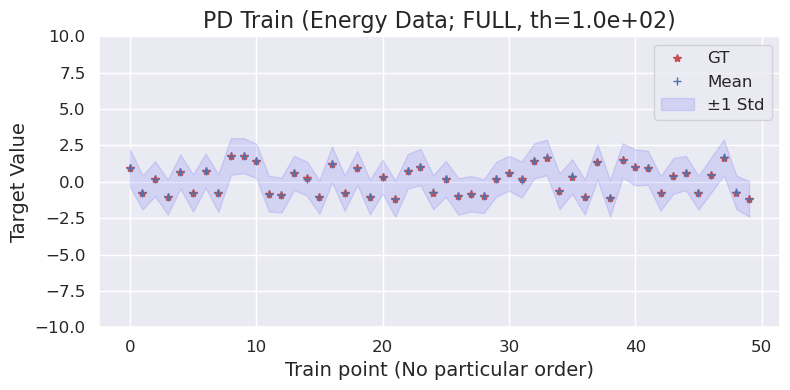

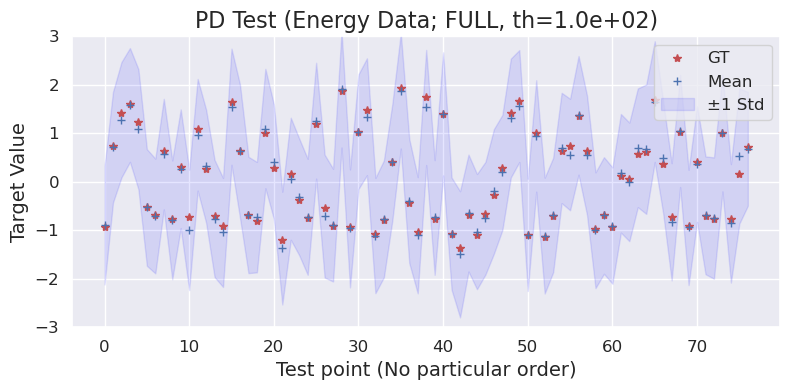

In [10]:
hess_type = 'full'

changed_cols = ['hess_type', 'low_rank', 'low_rank_th']
p_fixed = {k:v[0] for k, v in params.items() if k not in changed_cols}
best_setting = dict(query_df(res_df, dict(hess_type=hess_type)).sort_values(by='nll_test', ascending=True).iloc[0])
conf = p_fixed | {k:v for k, v in best_setting.items() if k in changed_cols}

w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
    nn_w_trained, x, y, conf_map['gamma_w'], 
    conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
)

n_train_show = 50
plot_prediction(
    y[:n_train_show], 
    forward_nn(nn_w_trained, x[:n_train_show, :]), 
    predict_std_nn(nn_w_trained, w_cholesky, x[:n_train_show, :], conf['beta_e'], n_samples=50), 
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data; {conf["hess_type"].upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, 
    forward_nn(nn_w_trained, x_test), 
    predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50), 
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data; {hess_type.upper()}, th={conf["low_rank_th"]:.1e})',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-3, 3)
)

##### PD Gif:

In [43]:
means_list = []
stds_list = []
for th in tqdm(params['low_rank_th']):
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=th)
    w_hess, w_cov, w_cholesky = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf_map['gamma_w'], 
        conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    means_list.append(forward_nn(nn_w_trained, x_test))
    stds_list.append(predict_std_nn(nn_w_trained, w_cholesky, x_test, conf['beta_e'], n_samples=50))

generate_prediction_gif(
    x_vals=params['low_rank_th'],
    y_gt=y_test,
    means_list=means_list,
    stds_list=stds_list,
    save_gif_path=SAVE_DIR / f'{DATA_NAME}_pred_dist.gif',
    xlabel=f'Test point ({DATA_NAME.capitalize()} Data)',
    ylabel='Target value',
    title_prefix=f'Predictive Distribution. {hess_type.upper()}, ',
    duration=1000,  # seconds per frame
    ylim=(-6, 6) 
)

100%|██████████| 8/8 [00:17<00:00,  2.19s/it]


##### Covariance matrix eigenvalues:

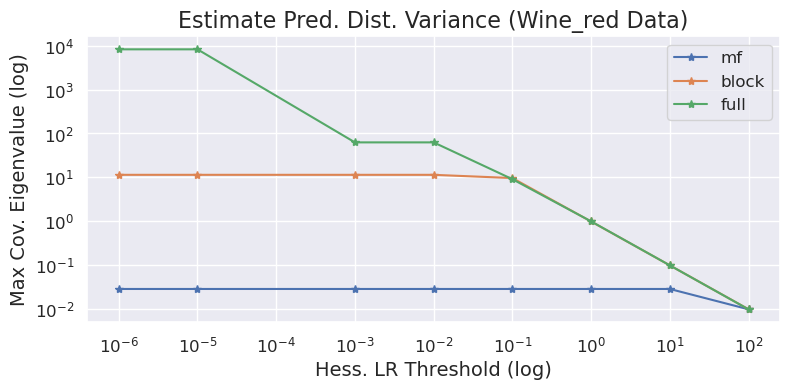

In [44]:
hess_dict, y_list = {}, []
for hess_type in params['hess_type']:
    conf = p_fixed | dict(hess_type=hess_type, low_rank=True, low_rank_th=1e-1)
    w_hess, _, _ = hess_cov_estimation_nn(
        nn_w_trained, x, y, conf_map['gamma_w'], 
        conf_map['beta_e'], conf['hess_type'], conf['low_rank'], conf['low_rank_th']
    )
    hess_dict[hess_type] = np.array(w_hess)
    ys = []
    for th in params['low_rank_th']:
        s, u = np.linalg.eigh(w_hess)
        mask = s >= th
        ys.append(1/min(s[mask]))
    y_list.append(ys)

plot_y_list(
    y_list, 
    x=params['low_rank_th'], 
    leg_list=params['hess_type'], 
    xlabel='Hess. LR Threshold (log)', 
    ylabel='Max Cov. Eigenvalue (log)',
    x_scale='log',
    y_scale='log',
    title=f'Estimate Pred. Dist. Variance ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_cov_max_ev_th.png'
)

#### GP Baseline:

RMSE Train: 0.6647234729150049; RMSE Test: 0.6706412903812703; NLL Test: 1.27119283722552


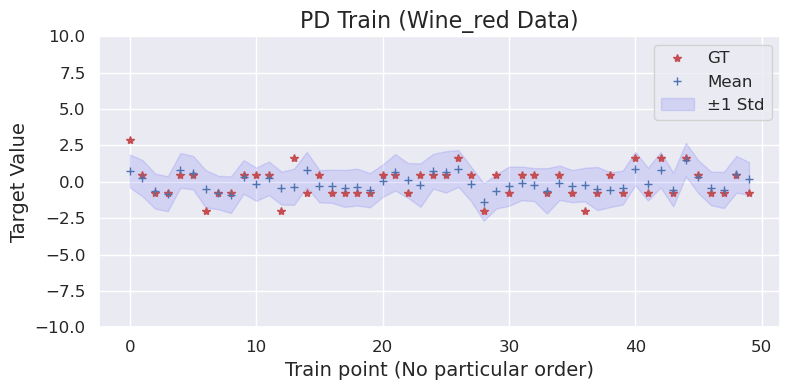

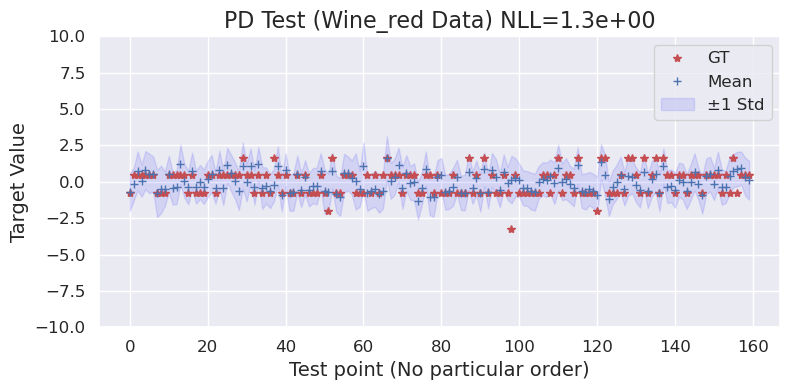

In [102]:
from sklearn.gaussian_process import GaussianProcessRegressor
import sklearn.gaussian_process.kernels as gp_kern

DATA_NAME = 'wine_red' # yacht, energy, concrete, wine_red
TEST_SIZE, SPLIT_SEED = 0.1, 1
TRANSFORM_X, TRANSFORM_Y, SCALER = True, True, 'std'
TRAIN = True

# Prepare the data:
x, x_test, y, y_test = load_transform_data(
    DATA_DIR / f'{DATA_NAME}.csv', TEST_SIZE, SPLIT_SEED, TRANSFORM_X, TRANSFORM_Y, SCALER)
x, x_test, y, y_test = map(jnp.array, [x, x_test, y, y_test])
dt = [x, x_test, y, y_test]
n_samples, d_dim = x.shape

#RES_DIR = Path(f'./artifacts/cov_comparison/gaussian_process/{DATA_NAME}/training_artifacts/')
#create_dir_if_not_exists(RES_DIR)

kernel = (
    gp_kern.RBF(length_scale=1, length_scale_bounds=(1e-3, 1e3)) 
    #+ gp_kern.WhiteKernel(noise_level=1, noise_level_bounds=(1e-10, 1e3))
)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.5,
    random_state=0,
    n_restarts_optimizer=15,
)
model.fit(x, y)

pred_mean_train, pred_std_train = model.predict(x, return_std=True)
pred_std_train += 1.0
pred_mean_test, pred_std_test = model.predict(x_test, return_std=True)
pred_std_test += 1.0
nll_test = nll(pred_mean_test, pred_std_test**2, y_test)
print(f"RMSE Train: {rmse(y, pred_mean_train)}; RMSE Test: {rmse(y_test, pred_mean_test)}; NLL Test: {nll_test}")

SAVE_DIR = Path(f'./artifacts/cov_comparison/gaussian_process/{DATA_NAME}/results/')
create_dir_if_not_exists(SAVE_DIR)

n_train_show = 50
plot_prediction(
    y[:n_train_show], pred_mean_train[:n_train_show], pred_std_train[:n_train_show],
    xlabel='Train point (No particular order)',
    ylabel='Target Value',
    title=f'PD Train ({DATA_NAME.capitalize()} Data)',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_train.png',
    ylim=(-10, 10)
)

plot_prediction(
    y_test, pred_mean_test, pred_std_test,
    xlabel='Test point (No particular order)',
    ylabel='Target Value',
    title=f'PD Test ({DATA_NAME.capitalize()} Data) NLL={nll_test:.1e}',
    save_path=SAVE_DIR / f'{DATA_NAME}_pred_dist_test.png',
    ylim=(-10, 10)
)